# Ajánlórendszerek

A modern digitális világban nap mint nap szinte láthatatlanul dolgoznak mögöttünk az ajánlórendszerek.  
Ezek azok az algoritmusok, amelyek segítenek eligazodni a hatalmas információhalmazban: megmutatják, mit érdemes megnézni, meghallgatni vagy megvásárolni.  
Céljuk, hogy **minden felhasználó számára személyre szabott tartalmakat** kínáljanak – olyat, ami a korábbi viselkedés, ízlés és döntések alapján valószínűleg érdekes lesz számára.

Másképp fogalmazva: az ajánlórendszerek az online világ „digitális ízléskalauzai”.  
Miközben mi csak kattintunk, ők tanulnak – folyamatosan elemzik, mit szeretünk, mit keresünk, és mit hagyunk figyelmen kívül.

### Miért tanuljuk ezt az *Adattudomány* tantárgyban?

Jogos a kérdés: ha az ajánlórendszerek mesterséges intelligenciát használnak, akkor miért nem a *Mesterséges intelligencia* kurzus részei?

A válasz egyszerű: **az ajánlórendszerek legfontosabb alapja nem maga az algoritmus, hanem az adat**, illetve mert az ajánlórendszerek a két terület határán helyezkednek el.  
Ahhoz, hogy jó ajánlásokat kapjunk, előbb meg kell érteni,hogyan gyűjtjük, tisztítjuk, normalizáljuk és strukturáljuk az adatokat, hogyan mérjük a hasonlóságot a felhasználók és termékek között, és hogyan készítünk belőlük értelmezhető, tanítható formát.

Az *Adattudomány* kurzus célja tehát, hogy **megalapozza azt az adatelemzési gondolkodásmódot**, amire később az MI-alapú modellek is épülnek.  
Itt még nem „tanítjuk a gépet gondolkodni”, hanem **megtanuljuk, hogyan beszéljünk az adatok nyelvén**.

### Példák a mindennapokból

- **Netflix** – Filmeket és sorozatokat ajánl az eddig megtekintett tartalmak alapján.  
- **Spotify** – Egyéni zenei ízlésre szabott lejátszási listákat generál, akár napi szinten.  
- **Amazon** – Termékeket ajánl a korábbi vásárlások, keresések és értékelések alapján.  
- **YouTube** – Videókat ajánl a nézési előzmények és hasonló felhasználók preferenciái szerint.  

Ezek a példák jól mutatják, hogy az ajánlórendszerek **nemcsak kényelmi funkciót töltenek be**,hanem alapvetően meghatározzák azt is, **milyen tartalmakkal találkozunk nap mint nap**. Ahogy haladunk előre, megismerjük, **milyen típusú ajánlórendszerek léteznek**, és **hogyan képesek „megérteni” az emberi ízlést** adatminták alapján.


## Hogyan találhatunk hasonló felhasználókat a termék minősítés alapján?

Tegyük fel, hogy egy filmnéző alkalmazást fejlesztünk, és szeretnénk megtalálni azokat a felhasználókat, akik **hasonló ízléssel** rendelkeznek.  
A hasonlóság mértéke kulcsfontosságú az ajánlórendszerekben, hiszen ha tudjuk, hogy két ember hasonlóan értékelte a filmeket, akkor **az egyik kedvenceit a másiknak is bátran ajánlhatjuk.**

Ahhoz, hogy ezt megértsük, kezdjünk egy **nagyon egyszerű, kétdimenziós példával.**  



Képzeljük el, hogy négy felhasználónk van: `A`, `B`, `C` és `D`.  
Mindannyian **két filmet értékeltek** – 1-től 5-ig terjedő skálán, ahol az 5 azt jelenti, hogy „nagyon tetszett”.  


In [86]:
# Az értékeléseket így tároljuk
a = [1, 2]
b = [2, 4]
c = [2.5, 4]
d = [4.5, 5]

Szemléltessük ezt vizuálissan is.

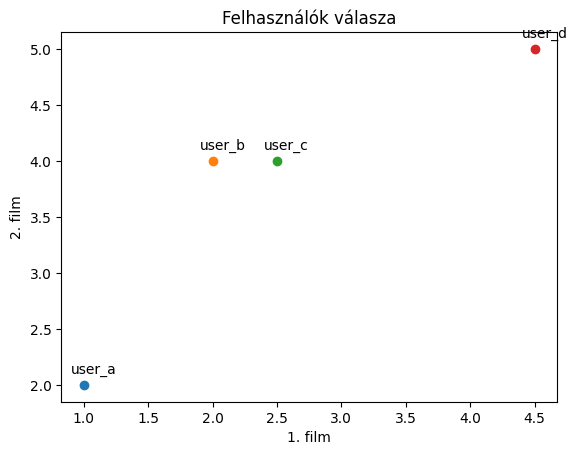

In [87]:
import matplotlib.pyplot as plt  # A matplotlib könyvtár grafikonrajzoláshoz

# Felhasználók azonosítói
labels = ['a', 'b', 'c', 'd']

# Végigmegyünk az összes felhasználón és kirajzoljuk őket egy síkban
for i, point in enumerate([a, b, c, d]):
    plt.scatter(point[0], point[1])  # Felhasználó pontjának kirajzolása
    # Felirat elhelyezése a pont közelében (pl. user_a, user_b, stb.)
    plt.text(point[0] - 0.1, point[1] + 0.1, s="user_" + labels[i])

# Tengelyfeliratok és cím beállítása
plt.title('Felhasználók válasza')  # Diagram címe
plt.xlabel('1. film')              # X tengely: első film értékelése
plt.ylabel('2. film')              # Y tengely: második film értékelése

# Grafikon megjelenítése
plt.show()


## A hasonlóság mérése távolság alapján

Ha a pontok közötti **távolságot** nézzük, az valóban jó módnak tűnik a hasonlóság becslésére, igaz?  
Minél közelebb vannak egymáshoz két felhasználó értékelései, annál inkább hasonló az ízlésük.  
A feladat tehát: kiszámolni, **milyen messze vannak egymástól a felhasználók a „véleménytérben”**.

Az egyik legegyszerűbb megközelítés erre az **euklideszi távolság**, amely azt méri, hogy két pont milyen messze van egymástól a síkon (vagy többdimenziós térben).  
A `scipy` könyvtárban található `spatial.distance.euclidean()` függvény ezt automatikusan kiszámolja nekünk.

**Megjegyzés**: A hasonlóság mérésről az előző órán már tanultunk.


In [3]:
from scipy import spatial  # Távolságok számításához szükséges modul

# Két film értékelései négy különböző felhasználótól
a = [1, 2]
b = [2, 4]
c = [2.5, 4]
d = [4.5, 5]

# Távolságok kiszámítása a C felhasználó és a többiek között
print('Távolság C -> A')
print(spatial.distance.euclidean(c, a))  # C és A közti euklideszi távolság

print('Távolság C -> B')
print(spatial.distance.euclidean(c, b))  # C és B közti euklideszi távolság

print('Távolság C -> D')
print(spatial.distance.euclidean(c, d))  # C és D közti euklideszi távolság

Távolság C -> A
2.5
Távolság C -> B
0.5
Távolság C -> D
2.23606797749979


Láthatjuk, hogy a C legközelebbi "szomszédja" (hozzá legjobban hasonló) felhasználó a B.

In [88]:
print('Távolság C -> B: ' + str(spatial.distance.euclidean(c, b)))

Távolság C -> B: 0.5


## Távolság ≠ Hasonlóság – avagy miért nem mindig elég az euklideszi távolság?

A távolság alapján való hasonlóságkeresés elsőre logikusnak tűnik:  
ha két felhasználó értékelései közel vannak egymáshoz, akkor hasonló az ízlésük, igaz?

De nézzük meg kicsit alaposabban.

Láttuk, hogy a `C` felhasználó legközelebbi „szomszédja” (tehát akihez a legkisebb távolság tartozik) a `B`.  
De mi történik, ha **A** és **D** között kell eldöntenünk, melyik áll közelebb C-hez?

A számítás szerint C valamivel **közelebb van D-hez**, mint A-hoz. 

Viszont ha ránézünk a **mintázatra**, érdekes dolgot látunk:  
- A és C **ugyanúgy aránylanak** a két filmhez – mindketten kétszer annyira kedvelik a második filmet, mint az elsőt.  
- D viszont **mindkét filmet egyformán jónak** tartja, így az ő ízlése inkább „minden tetszik egyformán” típusú.

Ez már előrevetíti, hogy a **puszta távolságmérés nem mindig elegendő** – néha a **mintázat (arány)** fontosabb, mint a tényleges értékek.



In [89]:
# Nézzük meg az értékeléseket újra, hogy jobban lássuk az arányokat
print('vélemény A')
print(a)
print('vélemény B')
print(b)
print('vélemény C')
print(c)
print('vélemény D')
print(d)

vélemény A
[1, 2]
vélemény B
[2, 4]
vélemény C
[2.5, 4]
vélemény D
[4.5, 5]


## Mi van, ha nem a távolság, hanem az irány számít?

Az előző példában láttuk, hogy az euklideszi távolság nem mindig tükrözi a valódi hasonlóságot:  
- néha két felhasználó **ugyanolyan mintázatban** értékel, csak más skálán.  

Például lehet, hogy az egyik mindenre 5-öst, a másik mindenre 3-ast ad – de az **arányok** közöttük mégis ugyanazok.

Hogyan tudnánk hatékonyan azonosítani az ilyen **mintázatbeli hasonlóságokat**, amelyeket a puszta távolság nem képes felismerni?

Egy lehetséges megoldás, ha **az origóból induló vektorokat** vizsgáljuk, és az ezek közötti **szöget** (cosine) figyeljük meg.  
Minél kisebb a szög, annál hasonlóbb a két értékelés mintázata – függetlenül attól, hogy az értékek abszolút nagysága mekkora.

Az alábbi ábra ezt szemlélteti: az origótól (0,0) induló vektorokat összekötjük a felhasználói pontokkal.


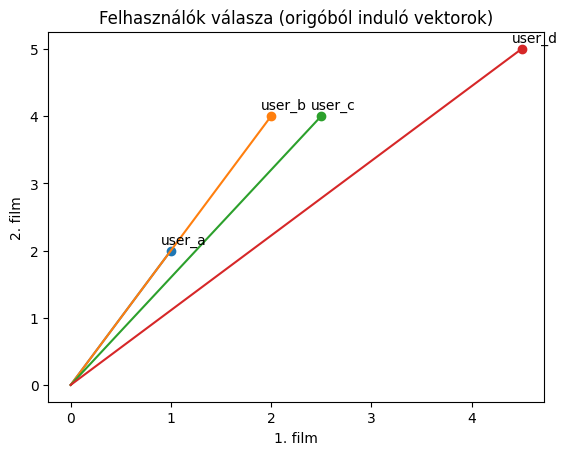

In [90]:
import matplotlib.pyplot as plt  # Ábrázoláshoz szükséges könyvtár

# Felhasználók azonosítói
labels = ['a', 'b', 'c', 'd']

# Minden felhasználót összekötünk az origóval (0,0)
for i, point in enumerate([a, b, c, d]):
    plt.plot([0, point[0]], [0, point[1]])  # Vonal az origóból a felhasználó pontjáig
    plt.scatter(point[0], point[1])         # Pont kirajzolása
    # Felhasználónév megjelenítése a pont mellett
    plt.text(point[0]-0.1, point[1]+0.1, s="user_" + labels[i])

# Diagram megjelenítése
plt.title('Felhasználók válasza (origóból induló vektorok)')
plt.xlabel('1. film')
plt.ylabel('2. film')
plt.show()


## 📐 A szögek és a koszinusz-hasonlóság értelmezése

A grafikonon négy egyenest látunk, amelyek az origóból indulnak,  
és mindegyik egy-egy felhasználót köt össze az általa adott filmértékelésekkel.  
Ezek a vonalak tehát **vektorokat** jelentenek – minden felhasználó ízlését egy irány jellemzi a térben.

Ha alaposan megfigyeljük, látható, hogy az **A** és **B** felhasználó egyenesei szinte **egybeesnek**,  
vagyis **ugyanabba az irányba mutatnak**. Ez azt jelenti, hogy a két felhasználó **ugyanabban az arányban** szereti az első és második filmet.  
A köztük lévő szög gyakorlatilag **nulla fok**, ami a lehető legnagyobb hasonlóságot jelenti.

Ahhoz, hogy a hasonlóságot **matematikailag is kifejezzük**,olyan függvényt keresünk, amely:
- kisebb szög esetén **nagyobb hasonlóságot** (vagy kisebb távolságot) ad,  
- nagyobb szög esetén pedig **kisebb hasonlóságot** (vagy nagyobb távolságot).

Erre tökéletesen megfelel a **koszinusz függvény**,  
amely 0° esetén 1-et, 90°-nál 0-t, 180°-nál pedig -1-et ad vissza.  

Vagyis:
- ha két vektor **ugyanabba az irányba mutat** → `cos(θ) ≈ 1` → **nagyon hasonló**,  
- ha **merőlegesek** → `cos(θ) = 0` → **nincs kapcsolat**,  
- ha **ellentétes irányúak** → `cos(θ) ≈ -1` → **teljesen ellentétes ízlés**.  




In [7]:
print('Koszinusz távolság C -> A')
print(spatial.distance.cosine(c,a))
print('Koszinusz távolság C -> B')
print(spatial.distance.cosine(c,b))
print('Koszinusz távolság C -> D')
print(spatial.distance.cosine(c,d))

Koszinusz távolság C -> A
0.004504527406047898
Koszinusz távolság C -> B
0.004504527406047898
Koszinusz távolság C -> D
0.015137225946083022


A C és A vektorok közötti kisebb szög, tehát alacsonyabb a koszinusz távolság.

In [8]:
print('Koszinusz távolság C -> A')
print(spatial.distance.cosine(c,a))

Koszinusz távolság C -> A
0.004504527406047898


Vegyük észre, hogy A és B felhasználó a koszinusz hasonlósági mérőszám alapján teljesen hasonlónak tekinthető, annak ellenére, hogy különböző értékelésekkel rendelkeznek.

In [9]:
print('A értékelése')
print(a)
print('B értékelése')
print(b)

A értékelése
[1, 2]
B értékelése
[2, 4]


Ez egy gyakori jelenség a való világban, és az A felhasználóhoz hasonló felhasználókat kemény értékelőknek nevezhetjük.

Ilyen például egy filmkritikus, aki mindig az átlagnál alacsonyabb értékelést ad, de a listáján szereplő elemek rangsorolásában hasonló az olyan átlagos értékelőkéhez, mint a B.

## MovieLens – az ajánlórendszerek „játéktesztere”

Most, hogy megértettük a hasonlóság fogalmát kis példán keresztül,nézzünk egy **valósabb, összetettebb feladatot**!

Az ajánlórendszerek kutatásában és oktatásában az egyik legismertebb adatforrás a **MovieLens-adatbázis**,amelyet a Minnesota Egyetem GroupLens projektje hozott létre.  
Ebben az adatbázisban több tízezer felhasználó **filmekhez adott értékelései** találhatók.  
Ez a gyakorlatban azt jelenti, hogy minden rekord azt mondja meg:  
- melyik felhasználó **milyen filmet**, **mikor**, és **milyen pontszámmal** értékelt.

A MovieLens adatok ideálisak az ajánlórendszerek tanulmányozásához, mert:
- valós felhasználói viselkedést tükröznek,  
- egyszerre alkalmasak **content-based** és **collaborative filtering** módszerek kipróbálására,  
- és jól kezelhetők Pythonban.

Ebben a példában a MovieLens adatbázis **egy kisebb, oktatási célra szánt részletét** fogjuk használni.


In [10]:
import pandas as pd

# oszlopnevek:
rating_colnames = ['userID', # felhasználó azonosítója
                   'movieID', # film azonosítója
                   'unix_timestamp', # időpont amikor a felhasználó értékelte a filmet
                   'rating' # értékelés 1-5 skálán, 5 a legjobb
                   ]

# egy kezelhető méretű részlete a MovieLens adatbázisnak:
ratings = pd.read_csv('https://raw.githubusercontent.com/rfarkas/student_data/main/MovieLens/movielens.small.ratings', sep='\t', names=rating_colnames)
ratings.head()

,userID,movieID,unix_timestamp,rating
0,617,255,874724710,4
1,617,286,874724727,4
2,617,298,874724754,4
3,617,185,874724781,4
4,617,173,874724843,4


## Nézzünk bele egy kicsit az adatokba

Milyen időszakból származnak az értékelések ?

In [11]:
from datetime import datetime
print(datetime.utcfromtimestamp(min(ratings.unix_timestamp))) # timestamp "olvasható" formátumra konvertálása
print(datetime.utcfromtimestamp(max(ratings.unix_timestamp)))

1997-09-20 03:05:10
1998-03-07 02:21:09


Hány értékelése van egy felhasználónak?

In [91]:
# Megnézzük, hány értékelést adott le egy-egy felhasználó
# A groupby('userID') csoportosítja az adatokat felhasználónként,
# a .size() pedig megszámolja, hány értékelés (sor) tartozik az adott userhez.
ratings.groupby('userID').size()


userID
1       245
2        89
4        38
5       484
7        32
       ... 
1003     35
1004     29
1006     48
1007     71
1008    237
Length: 751, dtype: int64

**Értelmezés:**
A kimenet azt mutatja, hogy például:
- a `userID = 1` felhasználó **245** filmet értékelt,
- a `userID = 2` felhasználó **89**-et,
- és így tovább…

Láthatjuk, hogy egyes felhasználók sok filmet értékeltek, mások viszont nagyon keveset.  
A legtöbb felhasználónak **75-nél kevesebb értékelése** van.
Ez az ajánlórendszerekben gyakori jelenség: az adatok **ritkák** (sparse data).  
Ez azt jelenti, hogy a felhasználó–film mátrixban rengeteg üres cella (hiányzó értékelés) lesz.


<Axes: >

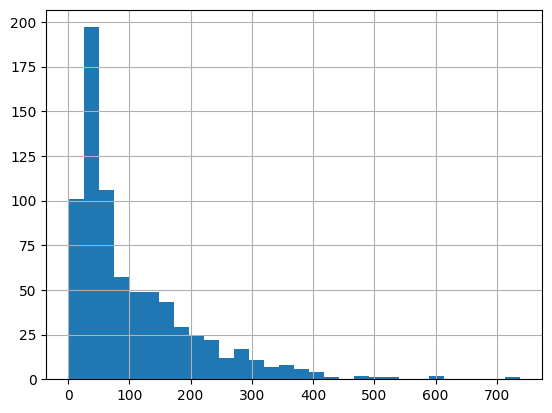

In [92]:
# Az értékelések eloszlásának vizualizálása hisztogrammal
# A bins=30 azt jelenti, hogy 30 oszlopra bontjuk az eloszlást
ratings.groupby('userID').size().hist(bins=30)

# A vízszintes tengely a leadott értékelések száma felhasználónként
# A függőleges tengely pedig azt mutatja, hány felhasználó tartozik az adott kategóriába


**Következtetés:**
A legtöbb felhasználó viszonylag kevés filmet értékelt,és csak néhány „aktív” felhasználó van, aki több száz értékelést adott le.

Ez a fajta eloszlás az ajánlórendszerek egyik legnagyobb kihívása:  
- a rendszernek akkor is ajánlást kell készítenie, ha valaki **kevés adatot** szolgáltatott.  

Ezt a problémát a szakirodalom **cold start problémának** nevezi.


<Axes: >

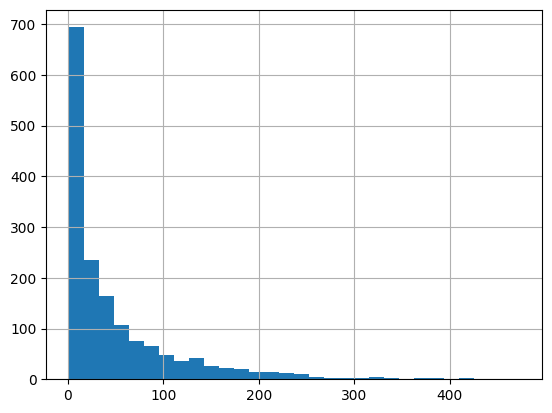

In [94]:
# Megnézzük, hány értékelés született egy-egy filmről.
# A groupby('movieID') csoportosítja az adatokat filmek szerint,
# majd a .size() megszámolja, hány értékelés tartozik az adott filmhez.
# A hist() segítségével hisztogramon ábrázoljuk az eloszlást.
ratings.groupby('movieID').size().hist(bins=30)  # ez (is) hatványeloszlás!


**Értelmezés:**

A hisztogramon látható, hogy:
- rengeteg olyan film van, amit **nagyon kevesen értékeltek**,  
- és csak néhány film kapott **nagyon sok értékelést**.  

Ez a tipikus **hatványeloszlás (power-law distribution)**:  
- kevés „népszerű” film sok értékelést kap, míg a legtöbb film kevés felhasználóhoz jut el.  

Ez a jelenség a legtöbb online platformon megfigyelhető — ugyanígy a zenéknél, könyveknél, weboldalaknál vagy YouTube-videóknál is.  
Néhány tartalom virális lesz, a többi viszont szinte láthatatlan marad.


In [95]:
# Filmek metaadatait is beolvashatjuk, hogy több információnk legyen a filmekről
# Ezeket az adatokat később összekapcsolhatjuk az értékelésekkel (movieID alapján)

item_colnames = [
    'movieID',  # azonosító, amivel összekötjük az értékelésekkel
    'title',    # film címe (zárójelben az évszámmal)
    'genre',    # műfaji címkék (pl. Action|Adventure|Comedy)
    'plot',     # rövid tartalmi leírás
    'actors'    # főbb szereplők nevei
]

# Szöveges állományok beolvasásakor az encoding (karakterkódolás) beállítása fontos,
# mert a latin betűs ékezetes karakterek hibát okozhatnak.
movies = pd.read_csv(
    'https://raw.githubusercontent.com/rfarkas/student_data/main/MovieLens/movielens.item.info',
    sep='\t',                     # az oszlopokat tabulátor választja el
    names=item_colnames,          # az előbb definiált oszlopneveket használjuk
    encoding='latin-1'            # karakterkódolás: így olvashatók a magyar ékezetek is
)

# Az első néhány film metaadatainak megtekintése
movies.head()


,movieID,title,genre,plot,actors
0,1,Toy Story (1995),"Animation,Children's,Comedy",A little boy named Andy loves to be in his roo...,"Bradley, Lisa (I);Derryberry, Debi;Freeman, Sa..."
1,2,GoldenEye (1995),"Action,Adventure,Thriller",When a deadly satellite weapon system falls in...,"Arthur, Michelle (I);Bond, Samantha (I);Dench,..."
2,3,Four Rooms (1995),Thriller,This movie features the collaborative director...,"Beals, Jennifer;Bellais, Monica Lee (I);Blair,..."
3,4,Get Shorty (1995),"Action,Comedy,Drama","Some guys get all the luck, whether they like ...","Arthur, Rebeca (I);Bega, Leslie;Burke, Carleas..."
4,5,Copycat (1995),"Crime,Drama,Thriller",Criminal profiler and psychologist Dr Helen Hu...,"Amos, Diane;Bingham, Gena;Bryson, Edith;Carmon..."


**Értelmezés:**
Ezek az adatok tartalmazzák a filmekről azokat az információkat,
amelyeket majd a **content-based (tartalomalapú)** ajánlórendszerek tudnak hasznosítani:
- filmcím, műfaj, színészek, rövid leírás stb.

A `movieID` lesz az a közös kulcs, amely segítségével
összekapcsoljuk az **értékeléseket (ratings)** és a **filmjellemzőket (movies)**.

Ezzel a lépéssel már előkészítettük az adatokat egy
komplexebb ajánlórendszer fejlesztéséhez.


In [98]:
# Az értékelések (ratings) és a filmadatok (movies) összekapcsolása
# A közös kulcs a 'movieID', amely mindkét táblában megtalálható.
# A how='left' biztosítja, hogy minden értékelés megmaradjon,
# akkor is, ha egyes filmekről nincs kiegészítő információ.
lens = pd.merge(ratings, movies, on='movieID', how='left')

# Az első néhány sor megtekintése az új, összekapcsolt táblából
lens.head()


,userID,movieID,unix_timestamp,rating,title,genre,plot,actors
0,617,255,874724710,4,My Best Friend's Wedding (1997),"Comedy,Romance","A woman who, by a promise made years earlier, ...","Abdoo, Rose;Alexander, Raci;Baggio, Aida;Bresl..."
1,617,286,874724727,4,The English Patient (1996),"Drama,Romance,War","Beginning in the 1930's, ""The English Patient""...","Belhassen, Sondos;Binoche, Juliette;Day, Phili..."
2,617,298,874724754,4,Face/Off (1997),"Action,Sci-Fi,Thriller","Sean Archer, a very tough, rugged FBI Agent. W...","Allen, Joan (I);Boyle, Lisa;Cho, Margaret;Gers..."
3,617,185,874724781,4,Psycho (1960),"Horror,Romance,Thriller",Phoenix officeworker Marion Crane is fed up wi...,"Beers, Prudence;Gregg, Virginia (I);Hitchcock,..."
4,617,173,874724843,4,The Princess Bride (1987),"Action,Adventure,Comedy,Romance",A kindly grandfather sits down with his ill gr...,"Brantley, Betsy;Dyson, Anne;Kane, Carol (I);Ma..."


In [99]:
# Megnézzük, melyek a legtöbbször értékelt filmek
# A groupby('title') csoportosítja az adatokat filmenként,
# a .size() megszámolja, hány értékelés tartozik egy-egy filmhez,
# majd a sort_values() csökkenő sorrendbe rendezi őket.
lens.groupby('title').size().sort_values(ascending=False)[:10]


title
Star Wars (1977)                  473
Return of the Jedi (1983)         423
Fargo (1996)                      417
Liar Liar (1997)                  396
Contact (1997)                    394
Scream (1996)                     383
Toy Story (1995)                  374
The English Patient (1996)        370
Independence Day (ID4) (1996)     366
Raiders of the Lost Ark (1981)    341
dtype: int64

## Az ajánlórendszerek típusai

Az ajánlórendszerek célja, hogy **segítsenek eligazodni a túl sok információ világában** – megmutatni, mi lehet érdekes számunkra, anélkül, hogy külön keresnénk.

Két fő típusuk van:

- **Kollaboratív szűrés (Collaborative Filtering):**  
  Az emberek viselkedése és értékelései alapján ajánl tartalmakat.  
  Például: *Netflix*, *Amazon* – „Azok a felhasználók, akik ezt nézték, azt is szerették.”
  
- **Tartalomalapú ajánlás (Content-Based Filtering):**  
  Az ajánlások az elemek jellemzői (pl. műfaj, kulcsszavak, leírás) alapján történnek.  
  Például: *Spotify*, *YouTube* – „Hasonló zenéket ajánlunk, mint amit most hallgatsz.”
  
- **Hibrid ajánlórendszerek:**  
  A két módszer kombinációja, amit a nagy platformok (Netflix, YouTube) is alkalmaznak.




## Kollaboratív szűrés (Collaborative Filtering)

Ez a megközelítés a **felhasználók viselkedésére** épül.  
Az alapgondolat egyszerű:  
- “Ha két ember korábban hasonlóan viselkedett (vagy értékelt), akkor valószínűleg a jövőben is hasonló ízlésük lesz.”

### Feltevés
- Hasonló emberek **hasonló dolgokat kedvelnek**.  
- Az ajánlás tehát nem a film tartalmán, hanem **a közösségi viselkedésmintákon** alapul.

### Két fő altípusa

1. **Felhasználó-alapú (User-Based):**  
   Olyan felhasználókat keresünk, akik **hasonló értékeléseket** adtak, mint az aktuális felhasználó.  
   - Ajánlás: „Más, hozzád hasonló emberek mit néztek?”
     

2. **Tétel-alapú (Item-Based):**  
   Azokat az elemeket (filmeket, zenéket stb.) ajánlja, amelyeket mások **együtt fogyasztottak**.  
   - Ajánlás: „Akik megnézték ezt a filmet, megnézték amazt is.”



### Matematikai háttér

A hasonlóság mérésére többféle módszer használható, például:
- **Koszinusz-hasonlóság** – a vektorok irányát hasonlítja össze,  
- **Pearson-korreláció** – az értékelések közötti lineáris kapcsolatot méri.

Ezek segítségével meg tudjuk mondani, mennyire hasonlít két felhasználó vagy két film egymásra.

### Egyszerű példa

| Film      | Felhasználó A | Felhasználó B | Felhasználó C |
|------------|----------------|----------------|----------------|
| Inception  | 5              | 4              | 5              |
| Matrix     | 4              | ?              | 4              |
| Titanic    | 1              | 2              | 1              |

Értelmezés:
- A és C hasonlóan értékelte az *Inception*-t és a *Titanic*-ot.  
- Valószínű, hogy C is **4 vagy 5 pontot** adna a *Matrix*-ra,mert az ízlésmintája hasonlít A-éhoz.

**Összegzés**

A kollaboratív szűrés tehát az **emberi viselkedés mintázataiból tanul**.  
Nem szükséges ismernie a film tartalmát, műfaját vagy szereplőit — csak azt figyeli, **ki mit szeretett**.  

Ez a módszer a legtöbb modern ajánlórendszer alapja, de jól kombinálható tartalomalapú megközelítéssel is.


### User-Based kollaboratív szűrés (Koszinusz hasonlóság)
A hasonló felhasználók keresése koszinusz hasonlósággal.

In [101]:
# Könyvtárak importálása
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity  # koszinusz-hasonlóság számításához

# ------------------------------------------------------------
# 1️MovieLens dataset betöltése
# ------------------------------------------------------------

# A MovieLens adatbázis egy kisebb, oktatási célra készült változatát töltjük be.
url = 'https://raw.githubusercontent.com/rfarkas/student_data/main/MovieLens/movielens.small.ratings'

# Az adatok tabulátorral ( \t ) vannak elválasztva, ezért sep='\t'.
# Az oszlopneveket (rating_colnames) korábban már definiáltuk.
df = pd.read_csv(url, sep='\t', names=rating_colnames)

# Az első néhány sor megtekintése – így ellenőrizzük, hogy az adatok megfelelően töltődtek be.
display(df.head())


,userID,movieID,unix_timestamp,rating
0,617,255,874724710,4
1,617,286,874724727,4
2,617,298,874724754,4
3,617,185,874724781,4
4,617,173,874724843,4


**Értelmezés:**
Minden sor egy értékelést jelent:
- `userID` → a felhasználó azonosítója  
- `movieID` → a film azonosítója  
- `rating` → az adott értékelés (1–5 skálán)  
- `unix_timestamp` → az értékelés időpontja  

Ezekből fogjuk felépíteni a **felhasználó–film mátrixot**, ahol
a sorok a felhasználók, az oszlopok pedig a filmek lesznek.
A mátrix cellái tartalmazzák az adott filmre adott pontszámot.


In [102]:
# ------------------------------------------------------------
# 2️Pivot tábla készítése (Felhasználó × Film mátrix)
# ------------------------------------------------------------

# A pivot() függvény átalakítja az adatokat úgy, hogy:
# - az index (sorok) a felhasználók,
# - az oszlopok a filmek,
# - a cellák pedig az értékelések.
ratings_matrix = df.pivot(index='userID', columns='movieID', values='rating')

# Az így létrejött mátrixot megtekintjük – itt már jól látható, hogy sok cella hiányzik (NaN),
# mivel nem minden felhasználó értékelt minden filmet.
ratings_matrix


movieID,1,2,3,4,5,6,7,8,9,10,...,1660,1662,1664,1671,1672,1675,1676,1677,1681,1682
userID,,,,,,,,,,,,,,,,,,,,,
1,NaN,NaN,NaN,5.0,2.0,NaN,4.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,2.0,NaN,4.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,5.0,3.0,3.0,4.0,2.0,NaN,4.0,5.0,5.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1003,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1004,4.0,NaN,NaN,NaN,NaN,NaN,3.0,NaN,3.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1006,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**Értelmezés:**

A létrejött mátrix a kollaboratív szűrés alapja:  
- Minden felhasználó egy **vektorként** értelmezhető (a filmek mentén).  
- Két felhasználó akkor **hasonló**, ha a vektoraik iránya közel azonos — ezt fogjuk kiszámolni a **koszinusz-hasonlóság** segítségével.

A hiányzó értékek (`NaN`) természetesek, hiszen senki sem látott minden filmet.  
Ezeket később külön kezelni fogjuk (pl. átlagolással vagy nullák helyettesítésével).


In [104]:
# ------------------------------------------------------------
# Hasonlóság számítása a felhasználók között
# ------------------------------------------------------------

# A cosine_similarity függvény a vektorok (felhasználók) közti szöget méri.
# Minél kisebb a szög, annál jobban hasonlítanak az értékelési mintázataik.
# fillna(0): a hiányzó értékeléseket 0-val helyettesítjük,
# mert a koszinusz-számítás nem tud üres (NaN) értékekkel dolgozni.
user_similarity = cosine_similarity(ratings_matrix.fillna(0))


In [105]:
# ------------------------------------------------------------
# Az eredmény megjelenítése Pandas DataFrame formában
# ------------------------------------------------------------

# A kapott mátrixot DataFrame-be alakítjuk, hogy jobban átlátható legyen.
# Az indexek és oszlopok ugyanazok, mint a felhasználók (userID-k),
# így minden cella egy hasonlósági értéket tartalmaz két felhasználó között.
user_sim_df = pd.DataFrame(
                                user_similarity,
                                index=ratings_matrix.index,
                                columns=ratings_matrix.index
                            )

# Az első 10 sor megjelenítése
display(user_sim_df.head(10))


userID,1,2,4,5,7,8,10,12,13,14,...,993,997,998,999,1000,1003,1004,1006,1007,1008
userID,,,,,,,,,,,,,,,,,,,,,
1,1.000000,0.295917,0.071248,0.483519,0.098268,0.217195,0.450719,0.385639,0.259418,0.217053,...,0.128548,0.190306,0.243591,0.225562,0.507494,0.102398,0.162106,0.168073,0.410971,0.473989
2,0.295917,1.000000,0.109341,0.393850,0.190304,0.158845,0.380343,0.212656,0.264279,0.132371,...,0.150859,0.163604,0.244638,0.229343,0.223312,0.143444,0.206623,0.239863,0.266354,0.286271
4,0.071248,0.109341,1.000000,0.064597,0.407654,0.024465,0.081588,0.000000,0.014530,0.019145,...,0.276536,0.000000,0.000000,0.076237,0.017118,0.268443,0.133158,0.063168,0.000000,0.027800
5,0.483519,0.393850,0.064597,1.000000,0.125402,0.298140,0.551340,0.288021,0.491664,0.288420,...,0.132280,0.178595,0.345842,0.250246,0.424046,0.114339,0.178328,0.247461,0.347088,0.490588
7,0.098268,0.190304,0.407654,0.125402,1.000000,0.037186,0.078177,0.000000,0.022903,0.067898,...,0.404256,0.000000,0.000000,0.087816,0.043670,0.324405,0.160768,0.041487,0.032382,0.085650
8,0.217195,0.158845,0.024465,0.298140,0.037186,1.000000,0.326419,0.130265,0.136223,0.126125,...,0.050632,0.112023,0.224572,0.124820,0.223544,0.029022,0.151616,0.199184,0.180732,0.148569
10,0.450719,0.380343,0.081588,0.551340,0.078177,0.326419,1.000000,0.274029,0.413627,0.227914,...,0.119084,0.192690,0.402608,0.332425,0.359745,0.035657,0.269263,0.315346,0.352014,0.447912
12,0.385639,0.212656,0.000000,0.288021,0.000000,0.130265,0.274029,1.000000,0.218480,0.114480,...,0.058004,0.149723,0.224659,0.138909,0.339575,0.008312,0.071056,0.205367,0.478023,0.309885
13,0.259418,0.264279,0.014530,0.491664,0.022903,0.136223,0.413627,0.218480,1.000000,0.092769,...,0.010024,0.085166,0.425173,0.224867,0.239932,0.015082,0.182651,0.250395,0.223910,0.309183


**Értelmezés:**

A `user_sim_df` egy **hasonlósági mátrix**,ahol minden érték 0 és 1 között van:

- `1.0` → teljesen azonos értékelési minta (ugyanaz az irány a vektortérben),  
- `0` → semmilyen hasonlóság nincs az értékelések között.

Minden sor egy felhasználót képvisel, és az oszlopok azt mutatják, hogy **ő mennyire hasonlít a többi felhasználóra**.

Például ha:

user_sim_df.loc[617, 102] = 0.86

akkor ez azt jelenti, hogy a 617-es felhasználó és a 102-es felhasználó értékeléseinek **mintázata 86%-ban egyezik**.

**Megjegyzés:**
- A főátló (diagonális) értékei mindig 1-ek, hiszen minden felhasználó önmagával azonos.  
- A mátrix szimmetrikus: a hasonlóság `A → B` megegyezik a `B → A` értékkel.


In [106]:
# ------------------------------------------------------------
# 5️Nézzünk egy konkrét példát
# ------------------------------------------------------------

# Felhasználó kiválasztása, akinek ajánlásokat szeretnénk adni
user_id = 1

# A user_sim_df mátrixból kiválasztjuk az adott felhasználó sorát,
# majd rendezzük a hasonlósági értékeket csökkenő sorrendbe.
# Így megkapjuk, kik a legjobban hasonló „szomszédok”.
user_sim_df.loc[user_id, :].sort_values(ascending=False).head(5)


userID
1      1.000000
837    0.615127
878    0.586167
817    0.583178
511    0.577042
Name: 1, dtype: float64

**Értelmezés:**
- A `1.000000` érték mindig saját magát jelöli (tökéletes hasonlóság).  
- A következő legnagyobb érték (pl. `0.615`) azt mutatja,  
  hogy az adott felhasználó értékelései **61,5%-ban irányban egyeznek** a kiválasztott felhasználóéval.  
- Minél magasabb a koszinusz-hasonlóság, annál valószínűbb, hogy a két ember hasonló filmeket szeret.


In [107]:
# ------------------------------------------------------------
# Megnézzük, mit nézett a kiválasztott felhasználó (user_id = 1)
# ------------------------------------------------------------

lens.loc[lens['userID'] == 1, :].sort_values(ascending=True, by='movieID').head(5)


,userID,movieID,unix_timestamp,rating,title,genre,plot,actors
36747,1,4,880314477,5,Get Shorty (1995),"Action,Comedy,Drama","Some guys get all the luck, whether they like ...","Arthur, Rebeca (I);Bega, Leslie;Burke, Carleas..."
38593,1,5,880568465,2,Copycat (1995),"Crime,Drama,Thriller",Criminal profiler and psychologist Dr Helen Hu...,"Amos, Diane;Bingham, Gena;Bryson, Edith;Carmon..."
36666,1,7,880313329,4,Twelve Monkeys (1995),"Drama,Sci-Fi",An unknown and lethal virus has wiped out five...,"Baldwin, Tiffany;D'Arcy, Cathy;Dawson, Jodi;El..."
36745,1,11,880314453,4,Seven (Se7en) (1995),"Crime,Thriller",NaN,NaN
35062,1,12,880139323,4,The Usual Suspects (1995),"Crime,Thriller","Following a truck hijack in New York, five con...","Amis, Suzy;Clunie, Michelle;Estabrook, Christi..."


**Értelmezés:**
Itt láthatjuk, hogy az 1-es felhasználó milyen filmeket értékelt,és milyen pontszámokat adott nekik.  
Ez segít megérteni, milyen ízlése van — pl. ha több krimi–dráma típusú filmet néz,akkor ezek az információk kulcsfontosságúak az ajánlásban.


In [109]:
# ------------------------------------------------------------
# Most megnézzük a leginkább hasonló felhasználó (pl. 837-es) értékeléseit
# ------------------------------------------------------------

lens.loc[lens['userID'] == 837, :].sort_values(ascending=True, by='movieID').head(5)


,userID,movieID,unix_timestamp,rating,title,genre,plot,actors
73556,837,4,887927588,5,Get Shorty (1995),"Action,Comedy,Drama","Some guys get all the luck, whether they like ...","Arthur, Rebeca (I);Bega, Leslie;Burke, Carleas..."
73263,837,7,887915414,5,Twelve Monkeys (1995),"Drama,Sci-Fi",An unknown and lethal virus has wiped out five...,"Baldwin, Tiffany;D'Arcy, Cathy;Dawson, Jodi;El..."
73431,837,8,887925497,5,Babe (1995),"Children's,Comedy,Drama",Farmer Hoggett wins a runt piglet at a local f...,"Acres, Mary;Alden, Jane (II);Bailey, Kimberly ..."
73291,837,9,887916203,5,Dead Man Walking (1995),Drama,A convicted murderer on Death Row and the nun ...,"Amurri Martino, Eva;Banks, Lenore;Bryant, Moll..."
73391,837,11,887924571,5,Seven (Se7en) (1995),"Crime,Thriller",NaN,NaN


**Értelmezés:**

A 837-es felhasználó a legjobban hasonlít az 1-eshez (0.615-ös koszinusz-hasonlóság).
Megnézve, mit nézett ő, kiderülhetnek olyan filmek, amelyeket az 1-es felhasználó még nem látott —  ezek lesznek **az ajánlás alapjai**.

Például, ha mindketten szeretik a *Get Shorty (1995)* című filmet, akkor a rendszer valószínűleg más, hasonló műfajú filmeket is ajánl majd az 1-es felhasználónak.


## Hogyan készít az ajánlórendszer tényleges ajánlást?

Most, hogy tudjuk, kik hasonlítanak egymásra, elkészíthetjük a *„Ha neked ez tetszett, ez is fog”* típusú ajánlást.

### Az alapötlet:
1. **Kiválasztjuk** a célszemélyt (pl. user_id = 1).  
2. **Megkeressük** a hozzá leginkább hasonló felhasználókat (pl. top 5).  
3. **Megnézzük**, ők milyen filmeket értékeltek magas pontszámmal.  
4. **Kiszűrjük** azokat, amiket a célszemély még *nem* látott.  
5. Ezekből lesznek az **ajánlott filmek**.

Az egyszerűség kedvéért most csak az egyik leginkább hasonló felhasználó (pl. 837) filmjeit használjuk fel az ajánláshoz.


In [111]:
# ------------------------------------------------------------
# Egyszerű ajánlás készítése hasonlóság alapján
# ------------------------------------------------------------

# 1. Célszemély kiválasztása
user_id = 1

# 2. Leginkább hasonló felhasználó kiválasztása (a saját magát nem számoljuk)
similar_users = (
                    user_sim_df.loc[user_id]
                    .sort_values(ascending=False)
                    .index[1:4]  # top 3 hasonló
                )
print(f"A {user_id}-es felhasználó leginkább hasonló szomszédai: {list(similar_users)}")

# 3. Filmek, amiket a célszemély már látott
user_seen = set(lens[lens['userID'] == user_id]['movieID'])

# 4. Filmek, amiket a hasonló felhasználók láttak
similar_users_movies = lens[lens['userID'].isin(similar_users)]

# 5. Szűrés: csak azokat a filmeket tartsuk meg, amelyeket a célszemély még nem látott
recommendations = similar_users_movies[~similar_users_movies['movieID'].isin(user_seen)]

# 6. Rendezzük az ajánlásokat az értékelés alapján (legjobban értékelt filmek előre)
top_recommendations = (
                        recommendations.sort_values(by='rating', ascending=False)
                        .drop_duplicates(subset='movieID')
                        .head(5)
                    )

# 7. Megjelenítés
display(top_recommendations[['title', 'genre', 'rating']])


A 1-es felhasználó leginkább hasonló szomszédai: [837, 878, 817]


,title,genre,rating
77077,Secrets & Lies (1996),Drama,5
73431,Babe (1995),"Children's,Comedy,Drama",5
73255,"Postino, Il (1994)","Drama,Romance",5
73444,The Omen (1976),Horror,5
73247,Leaving Las Vegas (1995),"Drama,Romance",5


**Értelmezés:**

A táblázatban megjelenő filmek azok, amelyeket:
- a hasonló ízlésű felhasználók **magasan értékeltek**,  
- a célszemély viszont **még nem látott**.

Ezek tehát a rendszer által **ajánlott filmek**.  
Ez a módszer a *„felhasználó-alapú kollaboratív szűrés”* egyik legegyszerűbb és legkönnyebben magyarázható példája.

**Továbbfejlesztési ötletek:**
- Több szomszéd bevonása (átlagolt súlyozás).  
- Csak 4 feletti értékelések figyelembevétele.  
- Súlyozás a hasonlósági értékekkel (pl. erősebb hatású a 0.9-es kapcsolat, mint a 0.6-os).  
- Hibrid megközelítés: tartalomalapú jellemzők bevonása (műfaj, kulcsszavak stb.).


## Item-Based kollaboratív szűrés (Pearson korreláció)

A tétel-alapú ajánlás lényege, hogy nem a felhasználókat, hanem **a filmeket** hasonlítjuk össze.
Ha két filmet sokan hasonlóan értékelnek, akkor azok valószínűleg hasonló stílusúak vagy élményt nyújtanak.

Példa:

Ha a legtöbb néző, aki szerette a *Matrix*-ot, a *Twelve Monkeys*-t is magasra értékelte, akkor a rendszer javasolhatja a másikat, ha valamelyiket már láttad.

A hasonlóságot itt **Pearson-korrelációval** mérjük, ami az értékelések közötti lineáris kapcsolatot mutatja.


In [113]:
# ------------------------------------------------------------
# Filmek közötti hasonlóság kiszámítása Pearson korrelációval
# ------------------------------------------------------------

# A .T (transpose) segítségével megfordítjuk a mátrixot:
# most a sorok a filmek, az oszlopok a felhasználók lesznek.
# Ezután a .corr(method="pearson") minden film–film párra kiszámítja a korrelációt.
item_similarity = ratings_matrix.T.corr(method="pearson")

# ------------------------------------------------------------
# Az eredmény megjelenítése Pandas DataFrame formában
# ------------------------------------------------------------
item_sim_df = pd.DataFrame(
                            item_similarity,
                            index=ratings_matrix.columns,   # filmek az indexben
                            columns=ratings_matrix.columns  # filmek az oszlopokban is
                        )

# Az első 10 sor megtekintése
display(item_sim_df.head(10))



movieID,1,2,3,4,5,6,7,8,9,10,...,1660,1662,1664,1671,1672,1675,1676,1677,1681,1682
movieID,,,,,,,,,,,,,,,,,,,,,
1,1.000000,0.155651,NaN,0.420084,0.386283,NaN,0.815657,0.244515,NaN,0.080075,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0.155651,1.000000,NaN,-0.125000,0.575800,NaN,0.437099,0.682540,NaN,0.370202,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0.420084,-0.125000,NaN,1.000000,-0.214087,NaN,0.494312,-1.000000,NaN,0.817498,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,0.386283,0.575800,NaN,-0.214087,1.000000,NaN,0.542980,0.392619,NaN,0.287589,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,0.815657,0.437099,NaN,0.494312,0.542980,NaN,1.000000,NaN,NaN,0.182574,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,0.244515,0.682540,NaN,-1.000000,0.392619,NaN,NaN,1.000000,NaN,0.063616,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**Értelmezés:**

A `item_sim_df` egy **film–film hasonlósági mátrix**,  
ahol minden cella egy Pearson-korrelációs értéket tartalmaz két film között.

Az értékek jelentése:
- `+1.0` → a két film értékelései tökéletesen együtt mozognak  
- `0` → nincs kapcsolat az értékelések között  
- `−1.0` → az egyik filmet pont akkor szeretik, amikor a másikat nem

**Fontos különbség:**
- A *User-Based* modell azt mondja: „Találj hasonló embereket.”  
- Az *Item-Based* modell azt mondja: „Találj hasonló filmeket.”

Ez a megközelítés stabilabb, ha sok a felhasználó, de viszonylag kevesebb az elem (pl. film, termék),
mert a filmek értékelési mintázata ritkábban változik, mint a felhasználók ízlése.


## Nézzünk egy példát – hogyan talál a rendszer hasonló filmeket?

Ebben a példában azt vizsgáljuk, hogy az Item-Based ajánlórendszer hogyan működik a gyakorlatban.

Az elv:
1. Kiválasztunk egy filmet (pl. `Toy Story (1995)`).
2. Megnézzük, mely más filmek értékelése **leginkább együtt változik** vele.
3. Az így kapott lista lesz a *„Hasonló filmek”* ajánlás.

A számítás a korábban elkészített `item_sim_df` mátrixból történik,
amely minden film–film párra tartalmazza a Pearson-korrelációt.


In [114]:
# ------------------------------------------------------------
# Film kiválasztása, amelyhez hasonlókat keresünk
# ------------------------------------------------------------
movie_id = 1  # Toy Story (1995) azonosítója

# A kiválasztott film sorát kivesszük a hasonlósági mátrixból,
# majd csökkenő sorrendben rendezzük az értékeket.
# Így megkapjuk a leginkább hasonló filmeket a korreláció alapján.
item_sim_df.loc[movie_id, :].sort_values(ascending=False).head(5)


movieID
1      1.000000
830    1.000000
419    0.956365
760    0.941184
448    0.919145
Name: 1, dtype: float64

**Értelmezés:**
- Az első érték mindig `1.0`, mert a film saját magával tökéletesen korrelál.  
- A többi érték (pl. `0.95`, `0.91`) azt mutatja, hogy más filmek értékelése
  mennyire hasonló a kiválasztotthoz.  
- Ezek lesznek a rendszer által *hasonlóként* azonosított filmek.


In [115]:
# ------------------------------------------------------------
# Nézzük meg a kiválasztott film adatait (pl. Toy Story)
# ------------------------------------------------------------
lens.loc[lens['movieID'] == 1, :].sort_values(ascending=True, by='userID').head(5)


,userID,movieID,unix_timestamp,rating,title,genre,plot,actors
26461,5,1,879466966,5,Toy Story (1995),"Animation,Children's,Comedy",A little boy named Andy loves to be in his roo...,"Bradley, Lisa (I);Derryberry, Debi;Freeman, Sa..."
16608,10,1,878148365,5,Toy Story (1995),"Animation,Children's,Comedy",A little boy named Andy loves to be in his roo...,"Bradley, Lisa (I);Derryberry, Debi;Freeman, Sa..."
17177,12,1,878402162,3,Toy Story (1995),"Animation,Children's,Comedy",A little boy named Andy loves to be in his roo...,"Bradley, Lisa (I);Derryberry, Debi;Freeman, Sa..."
32969,14,1,879987239,4,Toy Story (1995),"Animation,Children's,Comedy",A little boy named Andy loves to be in his roo...,"Bradley, Lisa (I);Derryberry, Debi;Freeman, Sa..."
35980,18,1,880177104,3,Toy Story (1995),"Animation,Children's,Comedy",A little boy named Andy loves to be in his roo...,"Bradley, Lisa (I);Derryberry, Debi;Freeman, Sa..."


In [116]:
# ------------------------------------------------------------
# Megnézzük a leginkább hasonló film értékeléseit
# ------------------------------------------------------------
# A korábbi lista alapján a legjobban hasonló film (pl. movieID = 830)
lens.loc[lens['movieID'] == 830, :].sort_values(ascending=True, by='userID').head(5)


,userID,movieID,unix_timestamp,rating,title,genre,plot,actors
47915,553,830,882397581,1,Power 98 (1995),"Action,Mystery,Thriller",NaN,NaN


**Értelmezés:**
A 830-as azonosítójú film például az *Action/Mystery/Thriller* kategóriába tartozik, és több közös nézője van a *Toy Story*-val, mint más filmeknek.  

A rendszer tehát nem a tartalom (műfaj, színész, leírás) alapján talál hasonlóságot, hanem az értékelési mintázatból — vagyis **az emberek viselkedéséből** tanul.


## Hogyan lesz az Item-Based hasonlóságból tényleges ajánlás?

A logika a következő:

1. **Válasszunk ki egy felhasználót** (pl. `user_id = 1`), akinek ajánlani szeretnénk.
2. Nézzük meg, **mely filmeket értékelt már** és milyen pontszámmal.
3. Ezekhez a filmekhez keressük meg a **hasonló filmeket** a `item_sim_df` mátrixból.
4. Számítsunk egy **súlyozott pontszámot** minden még nem látott filmre:
   - ha egy film sok hasonló filmhez kapcsolódik, amelyeket a felhasználó szeretett,  
     akkor nagy pontszámot kap.
5. A legmagasabb pontszámú filmek lesznek az **ajánlások**.


In [117]:
# ------------------------------------------------------------
# Egyszerű Item-Based ajánlás készítése
# ------------------------------------------------------------
import numpy as np

# 1. Célszemély kiválasztása
user_id = 1

# 2. Felhasználó értékeléseinek kinyerése
user_ratings = ratings_matrix.loc[user_id].dropna()

# 3. Üres dictionary az ajánlások gyűjtésére
scores = {}

# 4. Minden értékelt filmhez (amelyet a felhasználó látott) keressük meg a hasonlókat
for movie, rating in user_ratings.items():
    # A kiválasztott filmhez tartozó hasonlósági sor (más filmekkel)
    similar_movies = item_sim_df[movie].dropna()
    
    # Súlyozás a felhasználó értékelésével (pl. ha 5-öst adott, az nagyobb súlyt kap)
    for sim_movie, similarity in similar_movies.items():
        if sim_movie in user_ratings.index:
            continue  # már látta, nem ajánljuk újra
        
        # Ha a film még nincs a scores-ban, hozzáadjuk
        scores[sim_movie] = scores.get(sim_movie, 0) + similarity * rating

# 5. Eredmények DataFrame-be
recommendations = (
                        pd.DataFrame.from_dict(scores, orient='index', columns=['score'])
                        .sort_values(by='score', ascending=False)
                        .head(5)
                    )

# 6. Az ajánlott filmek neveinek kinyerése
recommended_titles = (
                        recommendations.merge(movies, left_index=True, right_on='movieID')[['title', 'genre', 'score']]
                    )

display(recommended_titles)


,title,genre,score
601,"American in Paris, An (1951)","Musical,Romance",211.513267
563,Tales from the Hood (1995),"Comedy,Horror",192.863542
889,Mortal Kombat: Annihilation (1997),"Action,Adventure",190.398361
924,Unforgettable (1996),"Sci-Fi,Thriller",179.360737
21,Braveheart (1995),"Action,Drama,War",178.953946


**Értelmezés:**

- A rendszer minden olyan filmet pontoz, amit a felhasználó még nem látott.  
- A pontszám annál nagyobb, minél több, általa kedvelt filmhez hasonlít az adott tétel.  
- A `score` oszlop tehát azt mutatja, **mennyire illik az adott film a felhasználó ízléséhez**.

**Eredmény:**  
Az 1-es felhasználóhoz legjobban illeszkedő filmek listája,  
amelyek között várhatóan több, az ízléséhez passzoló alkotás szerepel.

**Továbbfejlesztési lehetőségek:**
- A hasonlóságokat normalizálhatjuk (pl. osztás az összesített súlyokkal).  
- Figyelembe vehetjük csak a *pozitív* értékeléseket (pl. 4-5 pont).  
- A modell hibridizálható tartalomalapú jellemzőkkel (műfaj, színészek, kulcsszavak).


## A Surprise könyvtár – ajánlórendszerek egyszerűen

A fenti példákban *mi magunk építettük fel* az ajánlórendszer logikáját lépésről lépésre:  
- mátrixkészítés, hasonlóság-számítás, szomszédok keresése és ajánlások előállítása.

A valóságban azonban létezik egy kifejezetten **ajánlórendszerekhez fejlesztett Python-könyvtár**, amely mindezt automatikusan kezeli — ez a **[Surprise](https://surpriselib.com/)**.

### Mit tud a Surprise?
- Beépített adatstruktúrákat biztosít (train/test split, cross-validation, predikciós mátrixok).  
- Számos modell implementációja elérhető:
  - **KNNBasic, KNNWithMeans, KNNBaseline**
  - **SVD, SVD++**, **NMF (Non-negative Matrix Factorization)**
  - Random, NormalPredictor stb.
- Könnyedén kiszámítható vele az RMSE, MAE és más hibamérték is.

### Miért nem használjuk most a gyakorlatban?

A `scikit-surprise` csomag telepítése viszonylag **időigényes**, mert C++-ban írt függőségeket (pl. `scikit-surprise/surprise/similarities`) fordít le telepítéskor.  
Ez egy oktatási környezetben (pl. Jupyter Notebook, Coospace, Google Colab) gyakrantúl sok időt venne igénybe vagy fordítási hibát eredményezhetne.

Ezért ebben a fejezetben **manuálisan valósítottuk meg ugyanazt a logikát**,hogy a hallgatók lássák a belső működést és az algoritmus elvét.



**További információ és dokumentáció:**
- Hivatalos oldal: [https://surpriselib.com/](https://surpriselib.com/)
- GitHub repository: [https://github.com/NicolasHug/Surprise](https://github.com/NicolasHug/Surprise)



## Tartalomalapú ajánlás (Content-Based Filtering)

A korábbi példákban **a felhasználók viselkedéséből** indultunk ki (ki mit értékelt).  
Most azonban **magukból a filmek tartalmi jellemzőiből** – például műfajból, kulcsszavakból, leírásból – próbálunk következtetni a hasonlóságra.

### Alapelv:
Ha egy felhasználó kedvelt egy bizonyos filmet, akkor valószínűleg kedvelni fogja azokat is, **amelyek tartalmilag hasonlítanak** hozzá.

### Használt módszer: TF-IDF + Cosine Similarity
- A **TF-IDF** (Term Frequency – Inverse Document Frequency) egy szöveganalízis-módszer, amely kiemeli a legjellemzőbb szavakat egy dokumentumban (itt: film műfaj- vagy kulcsszó-leírás).
- A **Cosine Similarity** segítségével mérjük, hogy két film mennyire hasonlít egymásra a TF-IDF vektoraik alapján.


In [118]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# ------------------------------------------------------------
# Egyszerű filmadatbázis létrehozása
# ------------------------------------------------------------
movies = pd.DataFrame({
                        'title': ['Inception', 'Matrix', 'Interstellar', 'Titanic', 'Avatar', 'The Dark Knight'],
                        'genre': [
                            'Sci-Fi Action Thriller',
                            'Sci-Fi Action',
                            'Sci-Fi Drama',
                            'Romantic Drama',
                            'Sci-Fi Adventure',
                            'Action Thriller'
                        ]
                    })

display(movies)

# ------------------------------------------------------------
# TF-IDF vektorizáció a műfaj szöveges leírásra
# ------------------------------------------------------------
vectorizer = TfidfVectorizer()
tfidf_matrix = vectorizer.fit_transform(movies['genre'])

# ------------------------------------------------------------
# Koszinusz hasonlóság számítása az összes film között
# ------------------------------------------------------------
cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)

# A hasonlósági mátrix DataFrame formában, címkékkel
cosine_df = pd.DataFrame(cosine_sim, index=movies['title'], columns=movies['title'])
display(cosine_df.round(2))


,title,genre
0,Inception,Sci-Fi Action Thriller
1,Matrix,Sci-Fi Action
2,Interstellar,Sci-Fi Drama
3,Titanic,Romantic Drama
4,Avatar,Sci-Fi Adventure
5,The Dark Knight,Action Thriller


title,Inception,Matrix,Interstellar,Titanic,Avatar,The Dark Knight
title,,,,,,
Inception,1.00,0.80,0.44,0.00,0.40,0.79
Matrix,0.80,1.00,0.55,0.00,0.50,0.41
Interstellar,0.44,0.55,1.00,0.44,0.46,0.00
Titanic,0.00,0.00,0.44,1.00,0.00,0.00
Avatar,0.40,0.50,0.46,0.00,1.00,0.00
The Dark Knight,0.79,0.41,0.00,0.00,0.00,1.00


### Eredmény értelmezése

A fenti mátrix azt mutatja, hogy **mennyire hasonlítanak egymáshoz a filmek** a műfaj-leírás alapján.

- Az átlóban lévő értékek (`1.0`) azt jelentik, hogy egy film önmagával tökéletesen egyezik.
- A `cosine similarity` érték 0 és 1 között mozog:
  - **1 → teljesen azonos tartalom**
  - **0 → semmilyen közös jellemző nincs**

Például:
- Az *Inception* és a *Matrix* hasonlósága várhatóan magas (mindkettő „Sci-Fi Action”).
- Az *Inception* és a *Titanic* között viszont nagyon kicsi a hasonlóság, mivel teljesen más műfajba tartoznak.


In [119]:
# ------------------------------------------------------------
# Példa: „Inception”-höz hasonló filmek keresése
# ------------------------------------------------------------
movie_index = movies[movies['title'] == 'Inception'].index[0]

similar_scores = list(enumerate(cosine_sim[movie_index]))
similar_movies = sorted(similar_scores, key=lambda x: x[1], reverse=True)[1:4]

print("Az 'Inception'-höz leginkább hasonló filmek:")
for idx, score in similar_movies:
    print(f"{movies.iloc[idx]['title']} (hasonlóság: {score:.2f})")


Az 'Inception'-höz leginkább hasonló filmek:
Matrix (hasonlóság: 0.80)
The Dark Knight (hasonlóság: 0.79)
Interstellar (hasonlóság: 0.44)


**Értelmezés:**
Az ajánlás alapja most nem az értékelési viselkedés, hanem **a tartalmi hasonlóság**.  
Ha valaki kedvelte az *Inception*-t, a modell azt mondja:
- „Ajánlom neked a *Matrix*-ot vagy az *Interstellar*-t, mert ezek hasonló témájú Sci-Fi filmek.”

**Megjegyzés:**  
A Tartalomalapú módszer előnye, hogy új filmek esetén is működik (nem kell értékelés-adat), de hátránya, hogy a hasonlóságot csak a meglévő leírásokból tudja meghatározni.


## Filmek ajánlása TF-IDF hasonlóság alapján

Most, hogy kiszámoltuk a filmek közötti hasonlóságot, készítsünk egy függvényt, amely **egy kiválasztott filmhez automatikusan ajánl más, hasonló filmeket**.


In [120]:
# ------------------------------------------------------------
# Film ajánló függvény létrehozása
# ------------------------------------------------------------
def recommend_movies(movie_title, cosine_sim=cosine_sim):
    # 1. Film indexének lekérése a cím alapján
    idx = movies.index[movies['title'] == movie_title][0]
    
    # 2. Hasonlósági értékek kinyerése az adott filmhez
    sim_scores = list(enumerate(cosine_sim[idx]))
    
    # 3. Rendezés hasonlóság szerint (legnagyobb előre)
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    
    # 4. A top 3 hasonló film kiválasztása (az első mindig önmaga)
    sim_scores = sim_scores[1:4]
    
    # 5. Filmcímek lekérése az indexek alapján
    movie_indices = [i[0] for i in sim_scores]
    
    # 6. Csak a cím és műfaj megjelenítése
    return movies.iloc[movie_indices][['title', 'genre']]

# ------------------------------------------------------------
# Ajánlások lekérése egy adott filmhez
# ------------------------------------------------------------
recommended_movies = recommend_movies('Inception')
display(recommended_movies)


,title,genre
1,Matrix,Sci-Fi Action
5,The Dark Knight,Action Thriller
2,Interstellar,Sci-Fi Drama


### Hogyan működik ez?

1. A **TF-IDF** vektorizálja a filmek szöveges jellemzőit (pl. műfaj), és numerikus reprezentációt hoz létre.  
2. A **Cosine Similarity** méri, hogy két film „műfajvektora” mennyire hasonlít egymásra.  
3. A függvény az adott filmhez leginkább hasonlóakat választja ki — és ezeket ajánlja a felhasználónak.

Példa:
- Ha a felhasználó az *Inception* című filmet szerette,  
- akkor a modell a „Sci-Fi Action” és „Action Thriller” filmeket ajánlja, mint  
- a *Matrix*, *The Dark Knight* és *Interstellar*.


## Hibrid ajánlórendszer – Content-Based + Collaborative Filtering kombinációja

A hibrid megközelítés ötvözi a korábban tanultakat:

| Komponens | Alapja | Előnye |
|------------|--------|--------|
| **Tartalomalapú (Content-Based)** | Filmek jellemzői (pl. műfaj, leírás, kulcsszavak) | Új filmek esetén is működik |
| **Item-Based CF** | Más felhasználók értékelései alapján számolt hasonlóság | Valós nézői viselkedést tükröz |
| **Hibrid modell** | A kettő kombinálása súlyozottan | Pontosabb és stabilabb ajánlás |

A cél:  
- „Ajánlj olyan filmeket, amelyek **tartalmilag hasonlítanak** az adott filmre,  
- **és** amelyeket a hasonló felhasználók is kedveltek.”


In [121]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# ------------------------------------------------------------
# MovieLens adatok beolvasása (film + értékelés)
# ------------------------------------------------------------
ratings_url = 'https://raw.githubusercontent.com/rfarkas/student_data/main/MovieLens/movielens.small.ratings'
movies_url = 'https://raw.githubusercontent.com/rfarkas/student_data/main/MovieLens/movielens.item.info'

rating_cols = ['userID', 'movieID', 'rating', 'unix_timestamp']
movie_cols = ['movieID', 'title', 'genre', 'plot', 'actors']

ratings = pd.read_csv(ratings_url, sep='\t', names=rating_cols)
movies = pd.read_csv(movies_url, sep='\t', names=movie_cols, encoding='latin-1')

# Pivot tábla a filmek értékeléseihez
ratings_matrix = ratings.pivot(index='userID', columns='movieID', values='rating')


In [122]:
# Item-Based hasonlóság kiszámítása (értékelések alapján)
item_sim_cf = ratings_matrix.corr(method='pearson')


In [123]:
# ------------------------------------------------------------
# Content-Based hasonlóság (műfaj alapján TF-IDF + Cosine)
# ------------------------------------------------------------

# TF-IDF vektorizáló létrehozása
# A TF-IDF (Term Frequency – Inverse Document Frequency) súlyozás segít
# a szöveges jellemzőkből (itt: műfaj) numerikus reprezentációt készíteni.
# A stop_words='english' kiszűri az angol nyelv gyakori, jelentéktelen szavait (pl. "the", "and", stb.)
tfidf = TfidfVectorizer(stop_words='english')

# A filmek 'genre' (műfaj) oszlopának átalakítása TF-IDF mátrixszá
# A fillna('') gondoskodik róla, hogy az üres mezők ne okozzanak hibát
tfidf_matrix = tfidf.fit_transform(movies['genre'].fillna(''))

# 3️Koszinusz-hasonlóság számítása a filmek között
# A cosine_similarity kiszámolja, hogy két film műfajszövege mennyire hasonlít egymásra
# (értéke 0 és 1 között van, ahol 1 = teljes egyezés)
item_sim_content = pd.DataFrame(
                                cosine_similarity(tfidf_matrix, tfidf_matrix),  # hasonlósági értékek
                                index=movies['movieID'],                       # sorok: film ID-k
                                columns=movies['movieID']                      # oszlopok: film ID-k
                            )

# Eredmény:
# Egy négyzetes (N x N) mátrix, ahol minden cella azt mutatja,
# hogy két film mennyire hasonló műfaj alapján.


In [124]:
# ------------------------------------------------------------
# Hibrid hasonlósági mátrix létrehozása
# ------------------------------------------------------------

# Kombináljuk a két hasonlósági mátrixot (Collaborative + Content-Based)
# Az 'alpha' paraméter határozza meg, melyik módszer mennyire kap súlyt.
#   - Ha alpha = 0.8 → inkább a felhasználói értékelések (CF) dominálnak
#   - Ha alpha = 0.2 → inkább a tartalmi hasonlóság (TF-IDF műfaj) számít

alpha = 0.5  # egyenlő súlyozás a két módszer között (50%-50%)

# A .fillna(0) azért kell, mert a CF mátrixban sok NaN (hiányzó érték) lehet
# — ezeket nullával helyettesítjük, hogy a számítás működjön
hybrid_sim = (item_sim_cf.fillna(0) * alpha) + (item_sim_content.fillna(0) * (1 - alpha))

# Az eredmény:
# Egy új, hibrid hasonlósági mátrix (N x N), ahol minden filmhez
# figyelembe vesszük mind a felhasználói viselkedésből, mind a tartalomból származó információkat.


In [125]:
def hybrid_recommend(movie_title, top_n=5):
    # Film ID azonosítása
    movie_id = movies[movies['title'].str.contains(movie_title, case=False, na=False)]['movieID'].values[0]
    
    # Hasonlóságok rendezése
    sim_scores = hybrid_sim[movie_id].sort_values(ascending=False)
    
    # Top N hasonló film kiválasztása (saját magát kihagyva)
    similar_ids = sim_scores.index[1:top_n+1]
    
    # Filmek visszaadása
    return movies[movies['movieID'].isin(similar_ids)][['title', 'genre']]

# Példa:
recommendations = hybrid_recommend('Toy Story')
display(recommendations)


,title,genre
101,The Aristocats (1970),"Animation,Children's"
945,The Fox and the Hound (1981),"Animation,Children's"
1065,Balto (1995),"Animation,Children's"
1077,Oliver & Company (1988),"Animation,Children's"
1408,The Swan Princess (1994),"Animation,Children's"


### Eredmény értelmezése

A modell most kétféle szempontból ajánl egyszerre:

- **Ha egy film tartalmilag hasonló** (*pl. műfaj, téma*),
- **és más felhasználók is együtt értékelték** korábban, akkor a hibrid modell **magasabb hasonlóságot** ad neki.

Így a rendszer egyszerre tanul a **film jellemzőiből** és a **nézők viselkedéséből**.
